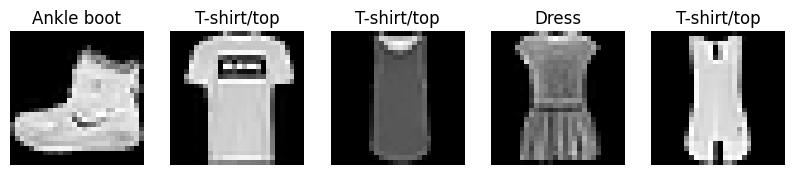

Fashion MNIST Data loaded and scaled! Training images: 60000


In [5]:
# ==========================================
# CELL 1: IMPORTS, DATA PREP & EXTRA VISUALIZATION
# ==========================================

# Import all the necessary tools from TensorFlow, Keras, and Scikit-Learn libraries.
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

# Load the Fashion MNIST dataset directly from TensorFlow's built-in datasets.
fashion_mnist = tf.keras.datasets.fashion_mnist

# Split the dataset automatically into training data (images/labels) and testing data.
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Scale the pixel values. Pixels range from 0 to 255. We divide by 255.0 to squeeze them between 0.0 and 1.0. 
# This normalization is absolutely crucial for Neural Networks to learn efficiently.
X_train = X_train / 255.0
X_test = X_test / 255.0

# Define a list of actual text names for the clothing items, because the 'y' labels only contain numbers (0 to 9).
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# EXTRA VISUALIZATION: Create a wide canvas to show the first 5 images from our training data.
plt.figure(figsize=(10, 2))

# Start a mini-loop to draw exactly 5 images side-by-side.
for i in range(5):
    # Select the specific subplot area (1 row, 5 columns, current index i+1).
    plt.subplot(1, 5, i+1)
    
    # Display the image array as a picture in black-and-white (grayscale).
    plt.imshow(X_train[i], cmap='gray')
    
    # Add a title above each image by matching the number label (y_train[i]) to our text list (class_names).
    plt.title(class_names[y_train[i]])
    
    # Hide the ugly X and Y axis pixel numbers around the pictures.
    plt.axis('off')

# Render the drawing to the screen.
plt.show()

print(f"Fashion MNIST Data loaded and scaled! Training images: {len(X_train)}")

In [6]:
# ==========================================
# CELL 2: EXPERIMENT LOOP & LOGBOOK GENERATION
# ==========================================

# 1. Define a list of dictionaries. Each dictionary is a unique experiment blueprint.
experiments = [
    {'id': 1, 'nodes': [32], 'epochs': 10, 'lr': 0.001, 'note': 'Baseline (1 Hidden Layer)'},
    {'id': 2, 'nodes': [64, 32], 'epochs': 10, 'lr': 0.001, 'note': 'Deeper Network (2 Layers)'},
    {'id': 3, 'nodes': [128, 64], 'epochs': 10, 'lr': 0.001, 'note': 'Wider & Deeper'},
    {'id': 4, 'nodes': [64, 32], 'epochs': 20, 'lr': 0.001, 'note': 'More Epochs (20)'},
    {'id': 5, 'nodes': [64, 32], 'epochs': 10, 'lr': 0.01, 'note': 'High Learning Rate (Fast but risky)'},
    {'id': 6, 'nodes': [64, 32], 'epochs': 10, 'lr': 0.0001, 'note': 'Low Learning Rate (Slow and steady)'},
    {'id': 7, 'nodes': [256, 128, 64], 'epochs': 10, 'lr': 0.001, 'note': 'Too Deep (Overfitting Risk)'},
    {'id': 8, 'nodes': [32, 16], 'epochs': 5, 'lr': 0.001, 'note': 'Too Few Epochs (Underfitting Risk)'},
    {'id': 9, 'nodes': [128, 64], 'epochs': 15, 'lr': 0.005, 'note': 'Balanced Learning Rate'},
    {'id': 10, 'nodes': [128, 64, 32], 'epochs': 20, 'lr': 0.001, 'note': 'Complex pattern testing'}
]

# Create an empty list to store the results of all 10 experiments.
results = []
print("Starting automated loop optimization for Images...\n")

# 2. The FOR LOOP that dynamically builds and tests each model.
for exp in experiments:
    
    # Initialize a fresh Sequential model.
    model = Sequential()
    
    # CRITICAL: Add a Flatten layer first. It takes the 28x28 grid of pixels and stretches it into a single line of 784 pixels.
    model.add(Flatten(input_shape=(28, 28)))
    
    # Dynamically add Dense layers based on the 'nodes' list in our blueprint.
    for node_count in exp['nodes']:
        model.add(Dense(node_count, activation='relu'))
            
    # Output layer: Exactly 10 nodes (because we have 10 clothing types). 
    # 'softmax' converts the 10 outputs into percentages (probabilities) that always add up to 100%.
    model.add(Dense(10, activation='softmax')) 
    
    # Compile the model. 'sparse_categorical_crossentropy' is the math formula specifically designed for multiple categories (0 to 9).
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=exp['lr']), metrics=['accuracy'])
    
    # Train the model silently (verbose=0) on the image data.
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=64, verbose=0)
    
    # Evaluate the trained model on the unseen test images.
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save the detailed results into our logbook list.
    results.append({
        'Experiment': f"Exp {exp['id']}",
        'Architecture': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Learning Rate': exp['lr'],
        'Accuracy': round(accuracy, 4),
        'Note': exp['note']
    })
    
    # Print a quick success message to the screen so we know it's working.
    print(f"✅ Exp {exp['id']} Completed -> Accuracy: {accuracy:.4f}")

# 3. Convert the results list into a Pandas DataFrame, save it as an Excel file, and display it beautifully.
df_logboek = pd.DataFrame(results)
df_logboek.to_excel("ML_Fashion_Loop_Logboek.xlsx", index=False)
display(df_logboek)

Starting automated loop optimization for Images...

✅ Exp 1 Completed -> Accuracy: 0.8621
✅ Exp 2 Completed -> Accuracy: 0.8752
✅ Exp 3 Completed -> Accuracy: 0.8799
✅ Exp 4 Completed -> Accuracy: 0.8846
✅ Exp 5 Completed -> Accuracy: 0.8651
✅ Exp 6 Completed -> Accuracy: 0.8531
✅ Exp 7 Completed -> Accuracy: 0.8797
✅ Exp 8 Completed -> Accuracy: 0.8593
✅ Exp 9 Completed -> Accuracy: 0.8779
✅ Exp 10 Completed -> Accuracy: 0.8878


,Experiment,Architecture,Epochs,Learning Rate,Accuracy,Note
0,Exp 1,[32],10,0.0010,0.8621,Baseline (1 Hidden Layer)
1,Exp 2,"[64, 32]",10,0.0010,0.8752,Deeper Network (2 Layers)
2,Exp 3,"[128, 64]",10,0.0010,0.8799,Wider & Deeper
3,Exp 4,"[64, 32]",20,0.0010,0.8846,More Epochs (20)
4,Exp 5,"[64, 32]",10,0.0100,0.8651,High Learning Rate (Fast but risky)
5,Exp 6,"[64, 32]",10,0.0001,0.8531,Low Learning Rate (Slow and steady)
6,Exp 7,"[256, 128, 64]",10,0.0010,0.8797,Too Deep (Overfitting Risk)
7,Exp 8,"[32, 16]",5,0.0010,0.8593,Too Few Epochs (Underfitting Risk)
8,Exp 9,"[128, 64]",15,0.0050,0.8779,Balanced Learning Rate
9,Exp 10,"[128, 64, 32]",20,0.0010,0.8878,Complex pattern testing


--- TRAINING FINAL CHAMPION MODEL ---
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8100 - loss: 0.7543 - val_accuracy: 0.8438 - val_loss: 0.5999
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8526 - loss: 0.5605 - val_accuracy: 0.8514 - val_loss: 0.5505
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.5095 - val_accuracy: 0.8562 - val_loss: 0.5102
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8643 - loss: 0.4829 - val_accuracy: 0.8633 - val_loss: 0.4885
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8681 - loss: 0.4672 - val_accuracy: 0.8601 - val_loss: 0.5008
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8707 - loss: 0.4538 - val_accuracy: 0.8653 - val_loss: 0.4678
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8730 - loss: 0.4437 - val_accuracy: 0.8677 - val_loss: 0.4640
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.

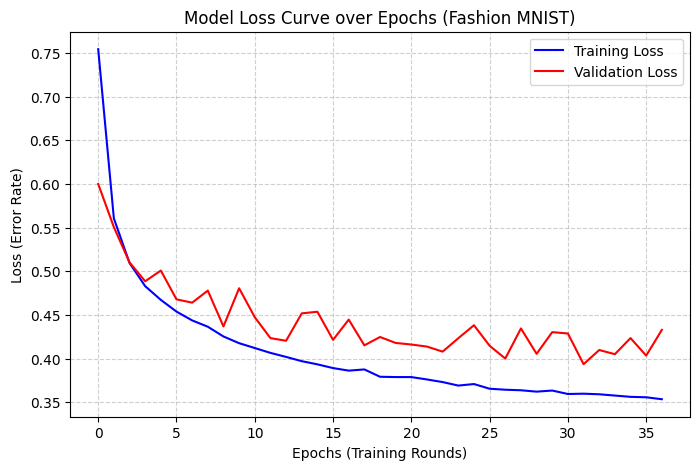

In [7]:
# ==========================================
# CELL 3: MANUAL OPTIMIZATION (FINAL MODEL) & LOSS PLOT
# ==========================================

print("--- TRAINING FINAL CHAMPION MODEL ---")

# 1. Building the final champion model manually to get the absolute best results.
final_model = Sequential([
    # Flatten the 2D image (28x28) into a 1D array.
    Flatten(input_shape=(28, 28)),
    
    # 1st Hidden Layer: 128 nodes with L2 Regularization (Weight Penalty) to prevent memorizing the training images.
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    
    # 2nd Hidden Layer: 64 nodes, also protected by L2 Regularization.
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    
    # Output Layer: 10 nodes for the 10 clothing classes using the 'softmax' probability function.
    Dense(10, activation='softmax')
])

# Compile the final model using a very stable learning rate (0.001).
final_model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 2. Early Stopping: Watches the validation loss. If the model stops learning new patterns for 5 rounds (patience=5), it stops.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Train the model. We save the output to the 'history' variable so we can draw a graph of the learning process.
history = final_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=64, callbacks=[early_stop], verbose=1)

# 4. PLOTTING THE LOSS PLOT
# Create a blank canvas for the graph.
plt.figure(figsize=(8, 5))

# Plot the blue line showing the error rate on the study materials (training data).
plt.plot(history.history['loss'], label='Training Loss', color='blue')

# Plot the red line showing the error rate on the unseen exam materials (validation data).
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

# Add titles, labels, a legend, and a grid to make the graph look professional.
plt.title('Model Loss Curve over Epochs (Fashion MNIST)')
plt.xlabel('Epochs (Training Rounds)')
plt.ylabel('Loss (Error Rate)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the graph.
plt.show()


--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.85      0.83      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.79      0.76      0.77      1000
       Dress       0.86      0.89      0.87      1000
        Coat       0.76      0.83      0.79      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.72      0.62      0.67      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



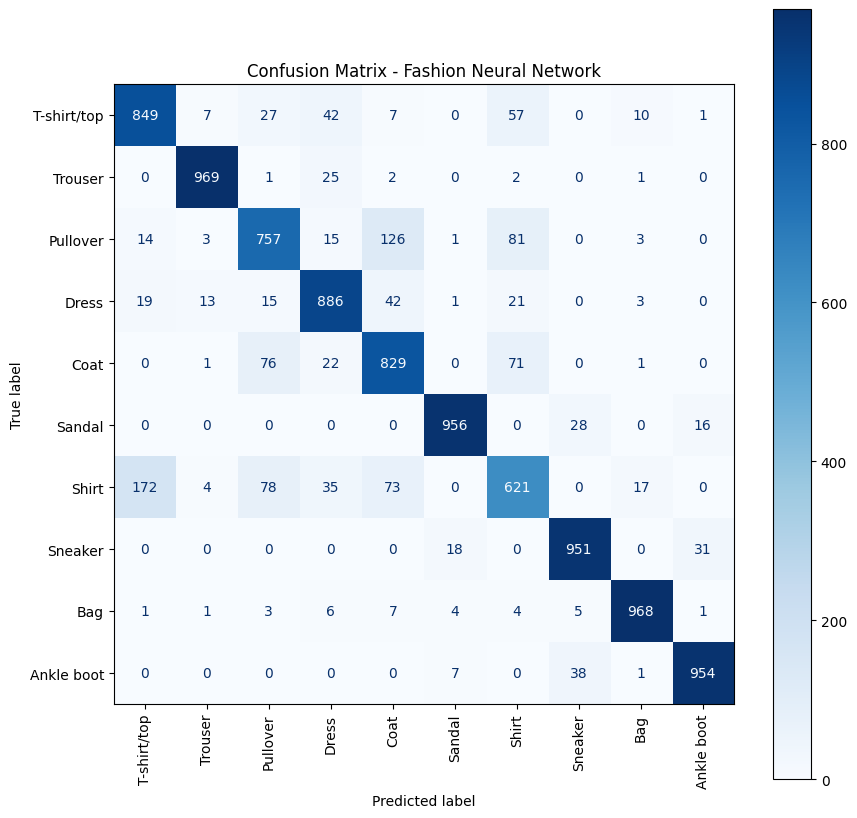

In [8]:
# ==========================================
# CELL 4: FINAL EVALUATION & CONFUSION MATRIX
# ==========================================

# 1. Ask the final model to predict the clothing types for all the unseen test images.
# This returns an array of 10 probabilities for each image.
y_pred_probs = final_model.predict(X_test, verbose=0)

# np.argmax: Looks at those 10 probabilities and picks the index of the highest one (e.g., if index 9 is 95%, it predicts 'Ankle boot').
y_pred_final = np.argmax(y_pred_probs, axis=1)

# 2. Print a detailed classification report comparing the model's guesses (y_pred_final) to the true answers (y_test).
# We use our 'class_names' list so the report prints actual clothing names instead of confusing numbers.
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_final, target_names=class_names))

# 3. Draw a large 10x10 Confusion Matrix to see exactly which clothing items the model confuses with each other.
fig, ax = plt.subplots(figsize=(10, 10))

# from_predictions: Calculates and plots the matrix grid. 'cmap=Blues' colors the boxes based on the numbers inside them.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Blues', display_labels=class_names, ax=ax, xticks_rotation='vertical')

# Add a title and display it.
plt.title("Confusion Matrix - Fashion Neural Network")
plt.show()